# Environment Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report,roc_auc_score,roc_curve
from xgboost import XGBClassifier

In [2]:
#!pip install flask joblib pandas numpy werkzeug

# Reading the Data

In [3]:
df = pd.read_csv('data/raw/loan_applications.csv')

In [4]:
df.sample(2)

,application_id,age,gender,marital_status,dependents,education,employment_type,annual_income_lakhs,loan_amount_lakhs,loan_tenure_months,interest_rate,credit_score,existing_loans,credit_history_years,monthly_emi_existing,property_area,has_co_applicant,debt_to_income,loan_to_income,default
88066,LN45822241,25,M,married,3,graduate,salaried,12.89,23.74,24,16.22,690.0,0,1.0,0.0,semi-urban,1,0.0,1.841738,0
24805,LN62700929,57,M,single,0,post_graduate,salaried,11.11,10.22,24,9.66,756.0,0,24.0,0.0,urban,1,0.0,0.919892,0


# SQL EDA

In [5]:
import sqlite3
conn = sqlite3.connect('data/loans.db')
df.to_sql('loan_applications',conn,if_exists='replace',index=False)

227000

In [6]:
query = "select * from loan_applications limit 10"
df_preview = pd.read_sql_query(query,conn)
print(f"----df_preview-----")
df_preview

----df_preview-----


,application_id,age,gender,marital_status,dependents,education,employment_type,annual_income_lakhs,loan_amount_lakhs,loan_tenure_months,interest_rate,credit_score,existing_loans,credit_history_years,monthly_emi_existing,property_area,has_co_applicant,debt_to_income,loan_to_income,default
0,LN18225942,59,F,single,1,post_graduate,salaried,9.25,33.97,12,8.27,543.0,1,8.0,14703.0,semi-urban,1,0.190742,3.672432,0
1,LN711935,49,M,married,3,under_graduate,salaried,18.60,67.48,24,9.09,775.0,0,9.0,0.0,semi-urban,0,0.000000,3.627957,0
2,LN67697552,35,M,single,1,graduate,business,4.92,5.45,48,8.82,822.0,1,NaN,4680.0,urban,0,0.114146,1.107724,0
3,LN6957837,63,M,married,1,post_graduate,business,7.75,10.82,36,14.03,614.0,2,20.0,13301.0,rural,0,0.205951,1.396129,0
4,LN45713536,28,M,married,1,under_graduate,salaried,14.72,20.46,84,15.40,741.0,3,0.0,28781.0,semi-urban,0,0.234628,1.389946,0
5,LN63530310,41,M,married,0,graduate,business,13.96,8.87,48,7.65,785.0,0,NaN,0.0,semi-urban,0,0.000000,0.635387,0
6,LN27576772,59,F,married,1,graduate,salaried,26.40,69.22,60,14.17,701.0,1,15.0,87068.0,semi-urban,0,0.395764,2.621970,0
7,LN89219016,39,M,married,1,graduate,salaried,10.42,14.85,180,8.66,801.0,1,16.0,25256.0,semi-urban,0,0.290856,1.425144,0
8,LN28865025,43,M,single,1,under_graduate,salaried,4.79,9.97,48,14.12,781.0,0,21.0,0.0,semi-urban,0,0.000000,2.081420,0
9,LN96056597,31,M,single,2,post_graduate,business,6.98,21.41,36,15.82,652.0,1,9.0,22948.0,urban,0,0.394521,3.067335,0


In [7]:
# Default rate by credit score band
q1 = """
select case 
when credit_score < 500 then 'Very Poor (<500)' 
when credit_score < 600 then 'Poor (500 - 599)' 
when credit_score < 700 then 'Fair (600 - 699)' 
when credit_score < 800 then 'Good (700 - 799)' 
else 'Excellent (800+)'
end as credit_band,
count(*) as total_apps,
sum("default") as defaults,
round(avg("default")*100,2) as default_rate_pct,
round(avg(loan_amount_lakhs),2) as avg_loan_lakhs
from loan_applications
where credit_score is not null
group by credit_band order by default_rate_pct desc
"""
q1_preview = pd.read_sql_query(q1,conn)
print(f"\n-------------DEFAULT RATE BY CREDIT SCORE BAND--------------\n")
q1_preview


-------------DEFAULT RATE BY CREDIT SCORE BAND--------------



,credit_band,total_apps,defaults,default_rate_pct,avg_loan_lakhs
0,Very Poor (<500),4259,2702,63.44,34.67
1,Poor (500 - 599),29324,9791,33.39,34.56
2,Fair (600 - 699),77474,10268,13.25,34.69
3,Good (700 - 799),76324,4078,5.34,34.75
4,Excellent (800+),31773,1158,3.64,34.88


In [8]:
# Risk by employment type
q2 = """
select employment_type,
count(*) as applications,
round(avg("default")*100,2) as default_rate,
round(avg(annual_income_lakhs),2) as avg_income,
round(avg(debt_to_income),3) as avg_dti
from loan_applications
group by employment_type order by default_rate desc
"""
q2_preview = pd.read_sql_query(q2,conn)
print(f"\n-------------RISK BY EMPLOYMENT TYPE--------------\n")
q2_preview


-------------RISK BY EMPLOYMENT TYPE--------------



,employment_type,applications,default_rate,avg_income,avg_dti
0,self_employed,56783,12.83,15.66,0.162
1,salaried,124959,12.80,15.51,0.162
2,business,45258,12.72,15.53,0.162


In [9]:
# High Risk Segment
q3 = """
select * from loan_applications
where credit_score < 550 and debt_to_income > 0.5 and existing_loans >=2
order by loan_amount_lakhs desc limit 10
"""
q3_preview = pd.read_sql_query(q3,conn)
print(f"\n-------------HIGH RISK SEGMENT--------------\n")
q3_preview


-------------HIGH RISK SEGMENT--------------



,application_id,age,gender,marital_status,dependents,education,employment_type,annual_income_lakhs,loan_amount_lakhs,loan_tenure_months,interest_rate,credit_score,existing_loans,credit_history_years,monthly_emi_existing,property_area,has_co_applicant,debt_to_income,loan_to_income,default


# EDA and Feature analysis

C:\Users\SABYA\AppData\Local\Temp\ipykernel_31880\120224571.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_clean.groupby(bins)['default'].mean().plot(kind='bar',ax=ax) #,color='coral'


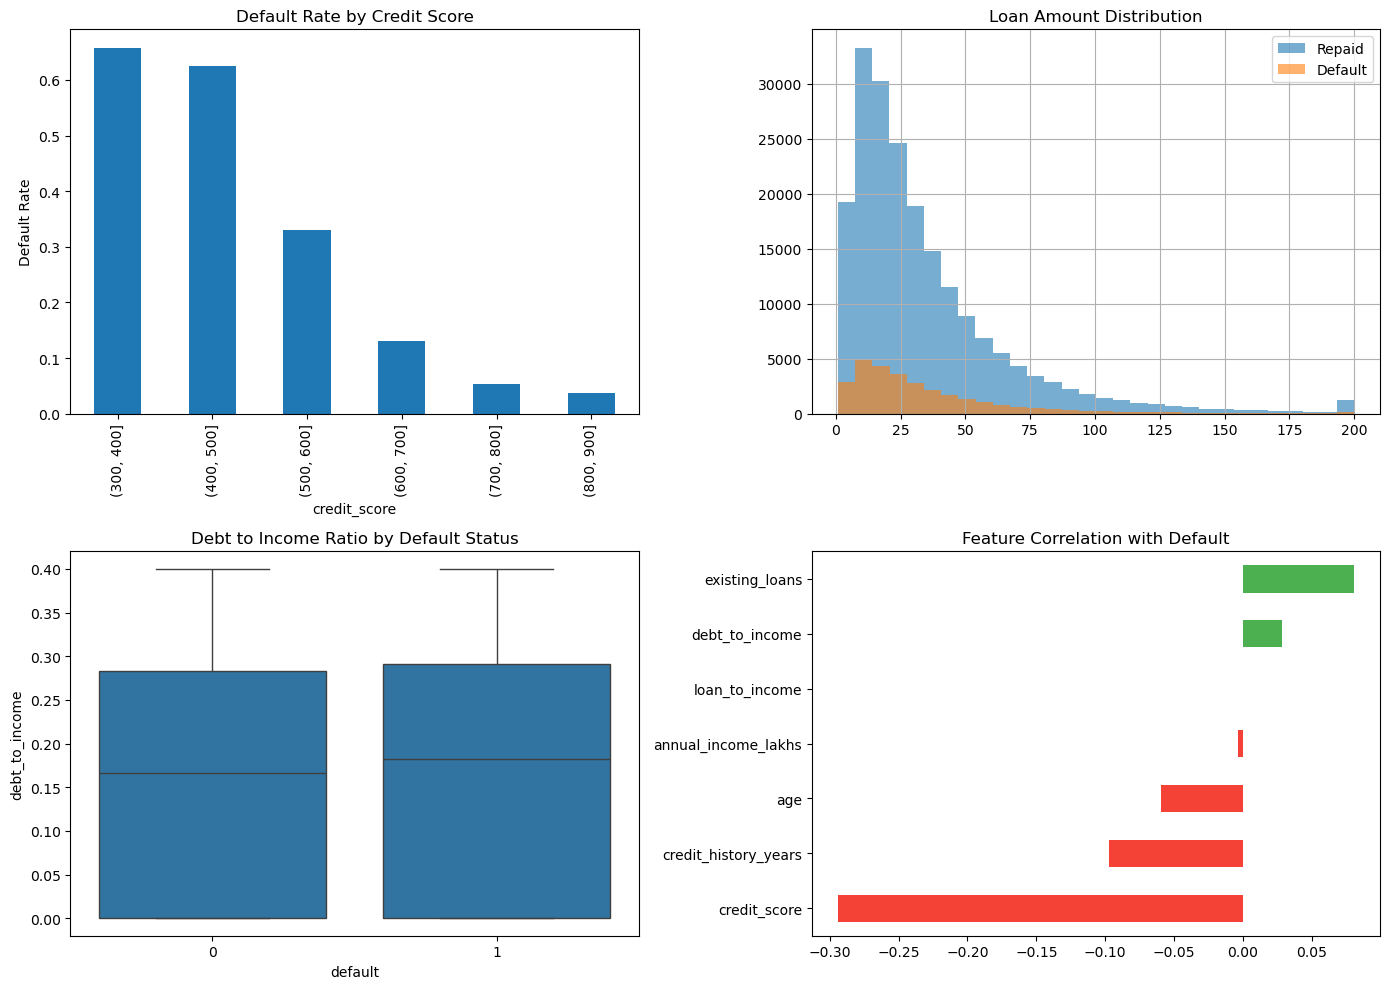

In [10]:
fig,axes = plt.subplots(2,2,figsize=(14,10))

# 1. Default rate by credit score
ax = axes[0,0]
df_clean = df.dropna(subset=['credit_score'])
bins=pd.cut(df_clean['credit_score'],bins=range(300,950,100))
df_clean.groupby(bins)['default'].mean().plot(kind='bar',ax=ax) #,color='coral'
ax.set_title('Default Rate by Credit Score')
ax.set_ylabel('Default Rate')

# 2. Loan Amount Distribution
ax = axes[0,1]
for label in [0,1]:
    df[df['default']==label]['loan_amount_lakhs'].hist(
        bins=30,alpha=0.6,ax=ax,label=f'{"Default" if label else "Repaid"}')
ax.set_title('Loan Amount Distribution')
ax.legend()

# 3. Debt-to-Income ratio
ax = axes[1,0]
sns.boxplot(data=df,x='default',y='debt_to_income',ax=ax)
ax.set_title('Debt to Income Ratio by Default Status')

# 4. Correlation of key features with default
ax = axes[1,1]
key_cols = ['credit_score','debt_to_income','loan_to_income','annual_income_lakhs','existing_loans','age','credit_history_years','default']
corr_with_default = df[key_cols].corr()['default'].drop('default').sort_values()
corr_with_default.plot(kind='barh',ax=ax, color=['#F44336' if v < 0 else '#4CAF50' for v in corr_with_default])
ax.set_title('Feature Correlation with Default')
plt.tight_layout()
plt.show()

# Feature Engineering (Weight of Evidence - WoE and Information Value - IV)

### Creating WoE and IV

In [11]:
def calculate_woe_iv(df,feature,target,bins=10):
    """ Calculate WoE and IV for a feature """
    if df[feature].dtype in ['float64','int64']:
        df.loc[:,f'{feature}_binned'] = pd.qcut(df[feature],bins,duplicates='drop')
        grouped=df.groupby(f'{feature}_binned',observed=True)[target]
    else:
        grouped=df.groupby(feature)[target]

    stats = pd.DataFrame({
        'total':grouped.count(),
        'events':grouped.sum(),
        'non_events':grouped.count()-grouped.sum()
    })
    stats['event_rate']=stats['events']/stats['events'].sum()
    stats['non_event_rate']=stats['non_events']/stats['non_events'].sum()
    stats['woe']=np.log(stats['non_event_rate']/stats['event_rate'].replace(0,0.001))
    stats['iv']=((stats['non_event_rate'])-(stats['event_rate']))* (stats['woe'])

    iv = stats['iv'].sum()
    return stats,iv

### Calculating IV for all features

In [12]:
iv_results = {}
for col in ['credit_score','annual_income_lakhs','debt_to_income','loan_to_income','age','existing_loans','credit_history_years']:
    _,iv = calculate_woe_iv(df.dropna(),col,'default')
    iv_results[col] = iv

iv_df = pd.DataFrame.from_dict(iv_results,orient='index',columns=['IV']).sort_values('IV',ascending=False)
iv_df['Predictive Power'] = iv_df['IV'].apply(lambda x:'Strong' if x >0.3 else ('Medium' if x > 0.1 else 'Weak'))
print(iv_df)

C:\Users\SABYA\AppData\Local\Temp\ipykernel_31880\1711894317.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[:,f'{feature}_binned'] = pd.qcut(df[feature],bins,duplicates='drop')
C:\Users\SABYA\AppData\Local\Temp\ipykernel_31880\1711894317.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[:,f'{feature}_binned'] = pd.qcut(df[feature],bins,duplicates='drop')
C:\Users\SABYA\AppData\Local\Temp\ipykernel_31880\1711894317.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a

                            IV Predictive Power
credit_score          0.805399           Strong
credit_history_years  0.121101           Medium
existing_loans        0.082491             Weak
age                   0.051489             Weak
debt_to_income        0.008040             Weak
annual_income_lakhs   0.000762             Weak
loan_to_income        0.000445             Weak


# Model Training with Imbalance Data handling

In [13]:
# Importing Libraries
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.metrics import classification_report,roc_auc_score,roc_curve

In [14]:
# Preparing Feature
cat_cols = ['gender','marital_status','education','employment_type','property_area']
num_cols = ['age','annual_income_lakhs','loan_amount_lakhs','loan_tenure_months','interest_rate','credit_score','existing_loans','credit_history_years','monthly_emi_existing','debt_to_income','loan_to_income','dependents','has_co_applicant']

for col in cat_cols:
    df[col] = LabelEncoder().fit_transform(df[col].astype(str))

X = df[num_cols + cat_cols].copy()
y = df['default']

In [15]:
# Train Test Split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [16]:
# modelling with SMOTE
models = {
    'Logistic Regression': ImbPipeline([
        ('imputer',SimpleImputer(strategy='median')),
        ('scaler',StandardScaler()),
        ('smote',SMOTE(random_state=42)),
        ('clf',LogisticRegression(max_iter=1000,random_state=42)),
    ]),
    'XGBoost': ImbPipeline([
        ('imputer',SimpleImputer(strategy='median')),
        ('smote',SMOTE(random_state=42)),
        ('clf',XGBClassifier(n_estimators=200,max_depth=5,learning_rate=0.1,scale_pos_weight=5,random_state=42,eval_metric='auc')),
    ]),
}

for name,pipe in models.items():
    pipe.fit(X_train,y_train)
    y_proba = pipe.predict_proba(X_test)[:,1]
    auc=roc_auc_score(y_test,y_proba)
    print(f"\n{name} | AUC:{auc:.4f}")
    print(classification_report(y_test,pipe.predict(X_test)))


Logistic Regression | AUC:0.7531
              precision    recall  f1-score   support

           0       0.94      0.69      0.80     39593
           1       0.24      0.68      0.36      5807

    accuracy                           0.69     45400
   macro avg       0.59      0.69      0.58     45400
weighted avg       0.85      0.69      0.74     45400


XGBoost | AUC:0.7760
              precision    recall  f1-score   support

           0       0.93      0.80      0.86     39593
           1       0.30      0.60      0.40      5807

    accuracy                           0.77     45400
   macro avg       0.62      0.70      0.63     45400
weighted avg       0.85      0.77      0.80     45400



In [17]:
os.makedirs('models',exist_ok=True)
joblib.dump(models['XGBoost'],'models/xgb_credit_model.pkl')
# joblib.dump(imputer,'models/imputer.pkl')
print(f"\n Model pipeline saved to models/xgb_credit_model.pkl")


 Model pipeline saved to models/xgb_credit_model.pkl


# Scorecard Conversion

### Convert model probability to a credit score like CIBIL Score (In range of 300 to 900)

In [18]:
def probability_to_score(probability,base_score=600,pdo=20,base_odds=50):
    """
    PDO = Points to double the odds
    base_score = score at base_odds
    """
    odds = (1-probability)/(probability+1e-10)
    factor = pdo/np.log(2)
    offset = base_score - factor * np.log(base_odds)
    score = offset + factor * np.log(odds)
    return np.clip(score,300,900).astype(int)

# Apply to test data
y_proba = models['XGBoost'].predict_proba(X_test)[:,1]
scores = probability_to_score(y_proba)

In [19]:
# Scorecard Analysis
scorecard_df = pd.DataFrame({
    'probability':y_proba,
    'credit_score':scores,
    'actual_default':y_test.values
})

In [20]:
# Score band analysis
scorecard_df['score_band'] = pd.cut(scorecard_df['credit_score'],bins=[300,500,600,700,800,900],labels=['Very High Risk','High Risk','Medium Risk','Low Risk','Very Low Risk'])

In [21]:
print(scorecard_df.groupby('score_band').agg(
    count=('actual_default','count'),
    default_rate=('actual_default','mean'),
    avg_probability=('probability','mean')
).round(3))

                count  default_rate  avg_probability
score_band                                          
Very High Risk  18983         0.229            0.571
High Risk       26416         0.055            0.198
Medium Risk         1         0.000            0.017
Low Risk            0           NaN              NaN
Very Low Risk       0           NaN              NaN


C:\Users\SABYA\AppData\Local\Temp\ipykernel_31880\2275344699.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(scorecard_df.groupby('score_band').agg(


# SHAP Interpretability

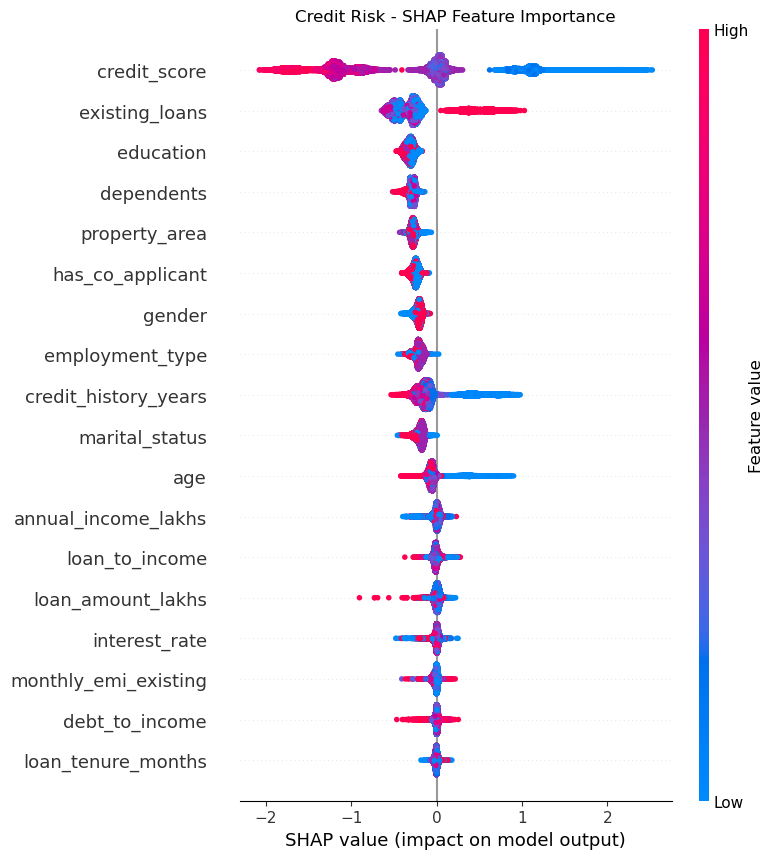

In [22]:
import shap

# Extract XGBoost from pipeline
xgb_model = models['XGBoost'].named_steps['clf']
X_test_processed = models['XGBoost'].named_steps['imputer'].transform(X_test)

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_processed)

# Global Importance
plt.title("Credit Risk - SHAP Feature Importance")
shap.summary_plot(shap_values,X_test_processed,feature_names = X_test.columns.to_list())

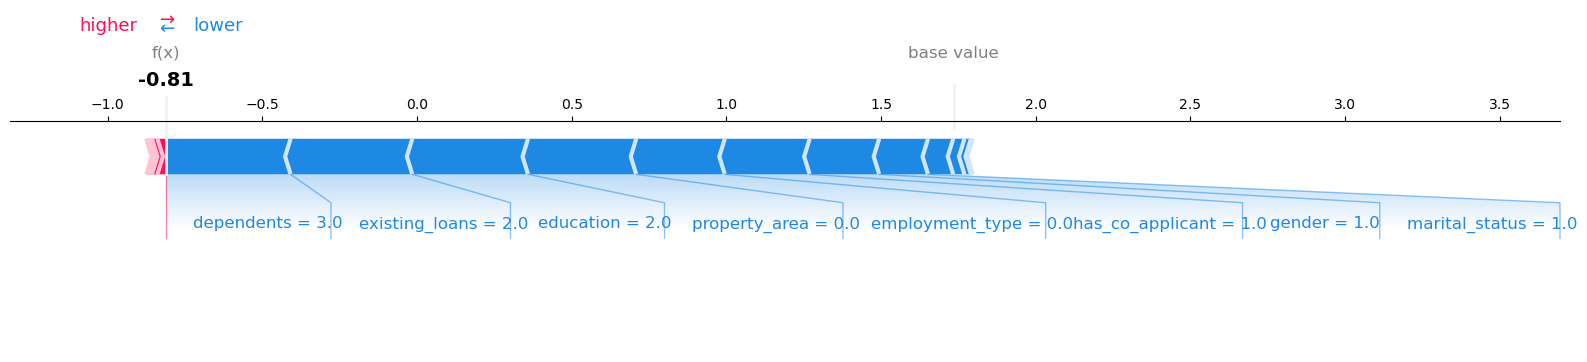

In [23]:
# Individual prediction explanation
idx = 0
shap.force_plot(explainer.expected_value,shap_values[idx],X_test_processed[idx],feature_names=X_test.columns.tolist(),matplotlib=True)

# FLASK API Deployment

In [24]:
from flask import Flask, request, jsonify
import joblib
import pandas as pd
import numpy as np
import threading
import sys

app = Flask(__name__)

# 1. Load model with robust error check
try:
    model = joblib.load('models/xgb_credit_model.pkl')
    print("SUCCESS: Model loaded successfully!")
except Exception as e:
    print(f"CRITICAL ERROR loading model: {e}")
    model = None

@app.route('/predict', methods=['POST'])
def predict():
    if model is None:
        return jsonify({"error": "Model is not loaded on the server. Check file path."}), 500
        
    try:
        data = request.json
        df = pd.DataFrame([data])
        
        # This is usually where XGBoost crashes if features don't match
        probability = model.predict_proba(df)[:, 1][0]
        
        score = int(np.clip(750 - 50/np.log(2) * np.log(5) +
                            50/np.log(2) * np.log((1-probability)/(probability+1e-10)), 300, 900))

        risk_category = ('Very High' if score < 450 else 'High' if score < 550
                         else 'Medium' if score < 650 else 'Low' if score < 750 else 'Very Low')

        return jsonify({
            'credit_score': score,
            'default_probability': round(float(probability), 4),
            'risk_category': risk_category,
            'decision': 'APPROVE' if score >= 650 else 'REVIEW' if score >= 550 else 'DECLINE'
        })
        
    except Exception as err:
        # This will print the EXACT error message in your Jupyter console!
        print(f"\n[SERVER ERROR DETECTED]: {str(err)}", file=sys.stderr)
        return jsonify({"error": "Internal Server Error", "details": str(err)}), 500

def run_flask():
    app.run(host='127.0.0.1', port=5000, debug=False, use_reloader=False)

# Start background thread
flask_thread = threading.Thread(target=run_flask)
flask_thread.daemon = True
flask_thread.start()
print("Flask server running...")

SUCCESS: Model loaded successfully!
Flask server running...
 * Serving Flask app '__main__'
 * Debug mode: off


 * Running on http://127.0.0.1:5000
Press CTRL+C to quit
127.0.0.1 - - [17/May/2026 15:03:39] "POST /predict HTTP/1.1" 200 -
127.0.0.1 - - [17/May/2026 15:03:41] "POST /predict HTTP/1.1" 200 -


# Testing the API

In [25]:
import joblib
model = joblib.load('models/xgb_credit_model.pkl')

# This will print the exact list of features the model is looking for
print(model.feature_names_in_)

['age' 'annual_income_lakhs' 'loan_amount_lakhs' 'loan_tenure_months'
 'interest_rate' 'credit_score' 'existing_loans' 'credit_history_years'
 'monthly_emi_existing' 'debt_to_income' 'loan_to_income' 'dependents'
 'has_co_applicant' 'gender' 'marital_status' 'education'
 'employment_type' 'property_area']


### Test Case Scenario 1

In [26]:
import requests
import pprint

url = "http://localhost:5000/predict"

# An example of a "Prime" (Low Risk) applicant profile
prime_applicant = {
    "age": 45,
    "annual_income_lakhs": 25.0,
    "loan_amount_lakhs": 15.0,
    "loan_tenure_months": 60,
    "interest_rate": 8.5,
    "credit_score": 820,            # Input feature for model
    "existing_loans": 0,
    "credit_history_years": 12,
    "monthly_emi_existing": 0,
    "debt_to_income": 0.0,
    "loan_to_income": 0.6,
    "dependents": 1,
    "has_co_applicant": 1,
    "gender": 1,                    # Use your specific encoding (e.g., 1 for M)
    "marital_status": 1,            # Use your specific encoding (e.g., 1 for Married)
    "education": 1,                 # Use your specific encoding
    "employment_type": 1,           # Use your specific encoding
    "property_area": 1              # Use your specific encoding
}

response = requests.post(url, json=prime_applicant)

print("Status Code:", response.status_code)
print("API Response Output:")
pprint.pprint(response.json())

Status Code: 200
API Response Output:
{'credit_score': 803,
 'decision': 'APPROVE',
 'default_probability': 0.0866,
 'risk_category': 'Very Low'}


In [27]:
import requests
import pprint

url = "http://localhost:5000/predict"

# Super-Prime (Ultra-Low Risk) Applicant Profile
super_prime_applicant = {
    "age": 48,
    "annual_income_lakhs": 35.0,       # High income
    "loan_amount_lakhs": 10.0,         # Low loan amount relative to income
    "loan_tenure_months": 36,          # Short tenure
    "interest_rate": 7.5,              # Premium interest rate
    "credit_score": 845,               # Pristine historical credit score
    "existing_loans": 0,               # No competing debt
    "credit_history_years": 18,        # Deep, established credit file
    "monthly_emi_existing": 0,         # No monthly liabilities
    "debt_to_income": 0.0,             # DTI = 0%
    "loan_to_income": 0.28,            # Very low loan-to-income ratio
    "dependents": 0,                   # Minimal financial dependents
    "has_co_applicant": 1,             # Co-applicant present (cuts risk multiplier)
    
    # Matching your numeric encodings for categorical values
    "gender": 1,                       
    "marital_status": 1,               
    "education": 1,                    
    "employment_type": 1,              
    "property_area": 1                 
}

response = requests.post(url, json=super_prime_applicant)

print("Status Code:", response.status_code)
print("API Response Output:")
pprint.pprint(response.json())

Status Code: 200
API Response Output:
{'credit_score': 866,
 'decision': 'APPROVE',
 'default_probability': 0.038,
 'risk_category': 'Very Low'}
